
# Universitat Oberta de Catalunya  
## Grado en Ingeniería Informática  
### Trabajo Final de Grado (TFG)

---

## Sistema de recomendaciones basado en técnicas de aprendizaje automático para ampliar la exploración de géneros musicales 
**Autor:** Marc Fernández Pereira  
**Bajo supervisión de:** Dra. María Moreno de Castro  
**Área:** Inteligencia Artificial  
**Semestre:** Otoño 2025  



---

## Índice

4. eXplainable Artificial Intelligence (XAI)

    - 4.1 Permutation Feature Importance (PFI)
        - 4.1.1 Función de scoring personalizada para Permutation Feature Importance
        - 4.1.2 Cálculo de la importancia de variables para K-Means k=4 sobre PCA
        - 4.1.3 Cálculo de la importancia de variables para K-Means k=7 sobre PCA
        - 4.1.4 Cálculo de la importancia de variables para K-Means k=4 sobre el conjunto estandarizado
        - 4.1.5 Cálculo de la importancia de variables para K-Means k=7 sobre el conjunto estandarizado
        - 4.1.6 Comparación e interpretación de la importancia de variables
    - 4.2 SHapley Additive exPlanations adaptado al clustering (SHAP-C)
        - 4.2.1 Introducción y contexto
        - 4.2.2 Visualización de resultados por clúster
            - 4.2.2.1 Clúster más compacto con distancia promedio de 1.35 (Clúster 1)
            - 4.2.2.2 Clúster menos compacto con distancia promedio de 2.05 (Clúster 0)
    - 4.3 Conclusiones

5. Cuantificación de la Incertidumbre (UQ)

    - 5.1 Gaussian Mixture Model (GMM)
        - 5.1.1 Selección del número de componentes y el tipo de matriz de covarianza
        - 5.1.2 Entrenamiento del modelo con 20 componentes
        - 5.1.3 Evaluación probabilística de asignaciones: certeza e incertidumbre
        - 5.1.4 Evaluación del modelo GMM mediante métricas de validación interna
        - 5.1.5 Conclusiones GMM

Guardado de información para los próximos cuadernos



In [1]:
# Este import centraliza todas las librerías estándar, scikit-learn y funciones personalizadas
from imports import *

c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Funciones

In [2]:

def cluster_silhouette_score(model, X, sample_size=10000):
    """
    Calcula el coeficiente de Silhouette como métrica de validación interna para clustering.
    Adaptada para su uso con permutation_importance de scikit-learn.
    
    :param model: Modelo de clustering entrenado (KMeans, GMM, etc.)
    :param X: Matriz de características (n_samples, n_features)
    :param sample_size: Tamaño de muestra para reducir coste computacional (por defecto 10000)
    :return: Coeficiente de Silhouette (valores entre -1 y 1)
    """
    labels = model.predict(X)
    return silhouette_score(X, labels, sample_size=sample_size, random_state=42)



### Carga de datos y modelos entrenados en el cuaderno de clustering


In [3]:
# Cargar dataset preprocesado
df = pd.read_csv('spotify_tracks_clean.csv')

# Cargar scaler y PCA
scaler = joblib.load('scaler_object.pkl')
pca = joblib.load('models/pca_95var.pkl')

# Variables utilizadas en el modelado de clustering
selected_vars = ['energy', 'acousticness', 'danceability', 'valence', 'tempo', 'liveness']

# Matriz de características original
X = df[selected_vars].copy()

# Datos estandarizados (mismas variables que en el cuaderno de modelado)
df_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=[f"{col}_norm" for col in selected_vars]
)

# Proyección PCA (mismas componentes que en el cuaderno de modelado)
X_pca = pca.transform(df_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Cargar modelos de clustering
kmeans_k4_estand = joblib.load('models/kmeans_k4_estand.pkl')
kmeans_k7_estand = joblib.load('models/kmeans_k7_estand.pkl')
kmeans_k4_pca = joblib.load('models/kmeans_k4_pca.pkl')
kmeans_k7_pca = joblib.load('models/kmeans_k7_pca.pkl')
gmm_n20_pca = joblib.load('models/gmm_n20_pca.pkl')


# 4. eXplainable Artificial Intelligence (XAI)

En el apartado “1.1.3 Una nueva oportunidad” se ha señalado que la IA Confiable constituye un concepto amplio y complejo cuyo propósito es definir un marco ético-social para el uso de la inteligencia artificial, con el fin de prevenir posibles daños a personas, ecosistemas u organizaciones, entre otros. Los tres pilares que fundamentan que una inteligencia artificial es confiable son la la legalidad, la ética y la robustez. Para alcanzar estos pilares un grupo de expertos de alto nivel sobre IA presentó el 8 de abril del 2019 una serie de directrices en el que se recogen los 7 requisitos presentados en la figura 3: agencia humana y supervisión, solidez técnica y seguridad, transparencia, diversidad, no discriminación y equidad, bienestar y responsabilidad [29][47].

En términos generales, la explicabilidad de la inteligencia artificial (Explainable AI), junto con la trazabilidad y la comunicación, constituye las tres dimensiones que definen la transparencia. Antes de explicar en que consiste la explicabilidad, conviene entender de manera clara qué significa la transparencia en este contexto. 
En el marco de la IA Confiable, la transparencia es la propiedad de un sistema inteligente que garantiza que las personas puedan acceder a la información  necesaria para comprender cómo se ha creado una inteligencia artificial y cómo toma sus decisiones. En la actualidad, existe hasta tres niveles distintos de transparencia:

- **Simulabilidad**: la capacidad de un ser humano de que pueda simular un modelo inteligente.
- **Descomponibilidad**: capacidad de poder entender cada parte del modelo independientemente.
- **Transparencia algorítmica**: la capacidad de comprender el funcionamiento del modelo y su manera de actuar frente a cualquier input.

Dado que la transparencia exige que las personas comprendan cómo se han desarrollado y cómo operan los sistemas de IA, la explicabilidad adquiere un papel fundamental en este proceso. En este sentido, la explicabilidad se entiende como la capacidad de un modelo para proporcionar una explicación clara y comprensible sobre que permita interpretar cómo y porqué toma determinadas decisiones o predicciones. 

Como se ha comentado en el apartado 1.1.3, en múltiples ocasiones los modelos inteligentes actúan como cajas negras, donde se introducen una serie de inputs que son procesados para generar outputs sin  que exista una comprensión explícita de los pasos intermedios ni de los factores que influyen en dichas decisiones. Este hecho puede convertirse en un problema, ya que no se puede predecir como actuará un modelo en situaciones inesperadas así ni cómo corregir si alguna cosa falla. 

En la actualidad, existen diferentes características para definir la taxonomía de la explicabilidad. A continuación, se presentan las más relevantes [48][49]:

En función del tipo de técnica:

- **Métodos agnosticos del modelo** (): técnicas que pueden aplicarse a cualquier tipo de algoritmo indepenedientemente de su complejidad o estructura interna. Los métodos más conocidos son LIME (*Local Interpretable Model Agnostic Explanation*) y SHAP(*Shapley Additive Exlanations*).
- **Métodos específicos del modelo** (): estas técnicas suelen estar integradas en el propio modelo de IA así que son métodos más específicos. Algunas técnicas populares son: los árboles de decisión o los modelos basados en reglas.

En función del comportamiento del modelo:

- ***ex-ante*** (*explainable-by-design*): algunos modelos como los lineales o los árboles de decisión tienen propiedades intrínsecas que facilitan su interpretación sin necesidad de generar modelos adicionales y añadir complejidad extra. Por ejemplo, los modelos lineales utilizan pesos que pueden explicar la importancia de cada característica. Por otro lado, los árboles pueden utilizar una característica a la hora de generar información mediante sus nodos para explicar dicha característica.
- ***post-hoc***: los modelos que no pueden explicar sus características de manera intrínseca, se consideran modelos post-hoc.


En función del alcance de la explicación:

- **Locales**: centradas en interpretar la predicción que realiza el modelo para una muestra o instancia concreta. 
- **Globales**: centradas en explicar el modelo de manera global.


En función del formato o naturaleza de la explicación generada. Existen multitud de técnicas que generan diferentes tipos de explicaciones.

A partir de esta clasificación, para el desarrollo de la explicabilidad se ha decidido seleccionar K-Means como modelo de referencia, ya que fue el algoritmo que ofreció los mejores resultados en la fase de modelado. El objetivo principal tratará de entender cómo y por qué k-means genera los diferentes clústeres y cómo asigna cada muestra a cada grupo.

Para abordar con esto, se decide implementar dos técnicas post-hoc agnósticas al modelo: Permutation Feature Importance (PFI) y Shapley Additive Explanation (SHAP), las cuales permiten analizar tanto la importancia global de las características como la contribución individual en la asignación de los clústeres.



## 4.1 Permutation Feature Importance (PFI)

La técnica Permutation Feature Importance se emplea en aprendizaje automático para evaluar la importancia de las características al medir cómo se altera el rendimiento del modelo cuando las características se permutan de manera aleatoria. Sin embargo, al tratarse de un problema no supervisado, este enfoque no puede aplicarse sobre predicciones. En su lugar, se utilizará PFI para analizar cómo cambian las métricas internas de calidad del modelo cuando se modifica la distribución de cada característica. Dicho de otro modo, en un proyecto de *clustering* la importancia de características se utiliza para visualizar que variables del conjunto de datos son más influyentes en la definición y formación de clústeres [46].

La extracción de la importancia de características otorga múltiples beneficios al proyecto:

- Aumento de la interpretabilidad: el hecho de detectar que características son más influyentes a la hora de generar las agrupaciones permite incrementar la interpretabilidad del modelo.
- Reducción de dimensionalidad: al igual que en el punto anterior, conocer qué características son más influyentes permite reducir la dimensionalidad del conjunto de datos descartando aquellas que no aportan información relevante a la formación de los clústeres. Además, esta reducción de dimensionalidad contribuye a mejorar el rendimiento del modelo desde el punto de vista del coste computacional. 
- Ingeniería de características: conocer la importancia de las características facilita la identificación de patrones relevantes y puede orientar la creación de nuevas características que capturen mejor la información del conjunto de datos.
- Mejora del rendimiento al agrupar observaciones: mediante la importancia de características se pueden detectar las menos influyentes para descartarlas del conjunto de datos y así contribuir a que los algoritmos de agrupación produzcan clústeres más significativos y precisos.

Como se ha comentado anteriormente, el uso de PFI en modelos no supervisados adopta un enfoque distintos frente a los algoritmos supervisados. Para comprender como debe funcionar PFI en este contexto se exponen los pasos que seguirá el algoritmo [46]:

- Se define una la función de agrupación, en este caso los modelos k-means entrenados en la fase de modelado.
- Se define una métrica de calidad de agrupación, en este caso se escoge el índice de la silueta. Esta métrica servirá para evaluar el rendimiento del modelo a la hora de permutar las diferentes características.
- El algoritmo, internamente permuta n veces los valores de una característica seleccionada arbitráriamente.
- Se vuelve a realizar el primer y el segundo paso después de permutar los valores de una característica.
- El algoritmo compara las métricas de calidad antes y después de permutar para determinar la importancia de la característica.

Así pues, se procede a implementar el método agnóstico pos-hoc Permutation Feature Importance:

### 4.1.1 Función de scoring personalizada para Permutation Feature Importance

Para poder extraer la importancia de las características permutando múltiples veces las variables del conjunto de datos, se debe establecer una función (scoring) que permita evaluar el modelo. Sin embargo, existe una diferencia fundamental en cómo funciona el algoritmo en aprendizaje supervisado y no supervisado. 

En el contexto del aprendizaje supervisado, el algoritmo PFI utiliza el parámetro $y$ para identificar las etiquetas reales del conjunto de datos. De esta manera, el algoritmo puede evaluar el rendimiento de un modelo supervisado en base a métricas como f1 Score, Accuracy Score, o r2 Score entre otros.  Sin embargo, para su uso bajo un contexto de aprendizaje no supervisado donde no se dispone de etiquetas reales, resulta indispensable declarar una función de scoring personalizada que ayude a medir el rendimiento de un modelo de *clustering* mediante una métrica como SH, elbow method o CH.

Para este propósito, se ha implementado la función **cluster_silhouette_score**, que adapta el cálculo del coeficiente de Silhouette para su uso con **permutation_importance**. Para comprobar que es correcta, se procede a visualizar los valores de silueta de los modelos desarrollados en el apartado de modelado:

In [4]:
# Cálculo del coeficiente de Silhouette para los modelos K-Means
# K-Means k=4 con PCA
sil_k4_pca = cluster_silhouette_score(kmeans_k4_pca, X_pca_df)

# K-Means k=7 con PCA
sil_k7_pca = cluster_silhouette_score(kmeans_k7_pca, X_pca)

# K-Means k=7 sin PCA (sobre datos estandarizados)
sil_k7_estand = cluster_silhouette_score(kmeans_k7_estand, df_scaled)

# K-Means k=4 sin PCA (sobre datos estandarizados)
sil_k4_estand = cluster_silhouette_score(kmeans_k4_estand, df_scaled)

print(f"Silhouette K-Means k=4 (PCA): {sil_k4_pca:.2f}")
print(f"Silhouette K-Means k=7 (PCA): {sil_k7_pca:.2f}")
print(f"Silhouette K-Means k=4 (Sin PCA): {sil_k4_estand:.2f}")
print(f"Silhouette K-Means k=7 (Sin PCA): {sil_k7_estand:.2f}")

c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Silhouette K-Means k=4 (PCA): 0.25
Silhouette K-Means k=7 (PCA): 0.20
Silhouette K-Means k=4 (Sin PCA): 0.24
Silhouette K-Means k=7 (Sin PCA): 0.18


### 4.1.2 Cálculo de la importancia de variables para K-Means k=4 sobre PCA

El primer paso que se ha realizado es la visualización de los resultados de PFI sobre el modelo K-Means con $k=4$ sobre PCA ya que, según las métricas de calidad extraídas en la fase de modelado, es el mejor modelo en términos de rendimiento. 


In [5]:
# Tomamos una muestra representativa del conjunto de datos para acelerar el proceso ya que computacionalmente es muy costosa
X_pca_sample = X_pca_df.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_pca.pkl'):
    p_importance_k4_pca = joblib.load('resultados_explicabilidad/p_importance_k4_pca.pkl')
else:
    p_importance_k4_pca = permutation_importance(
        kmeans_k4_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

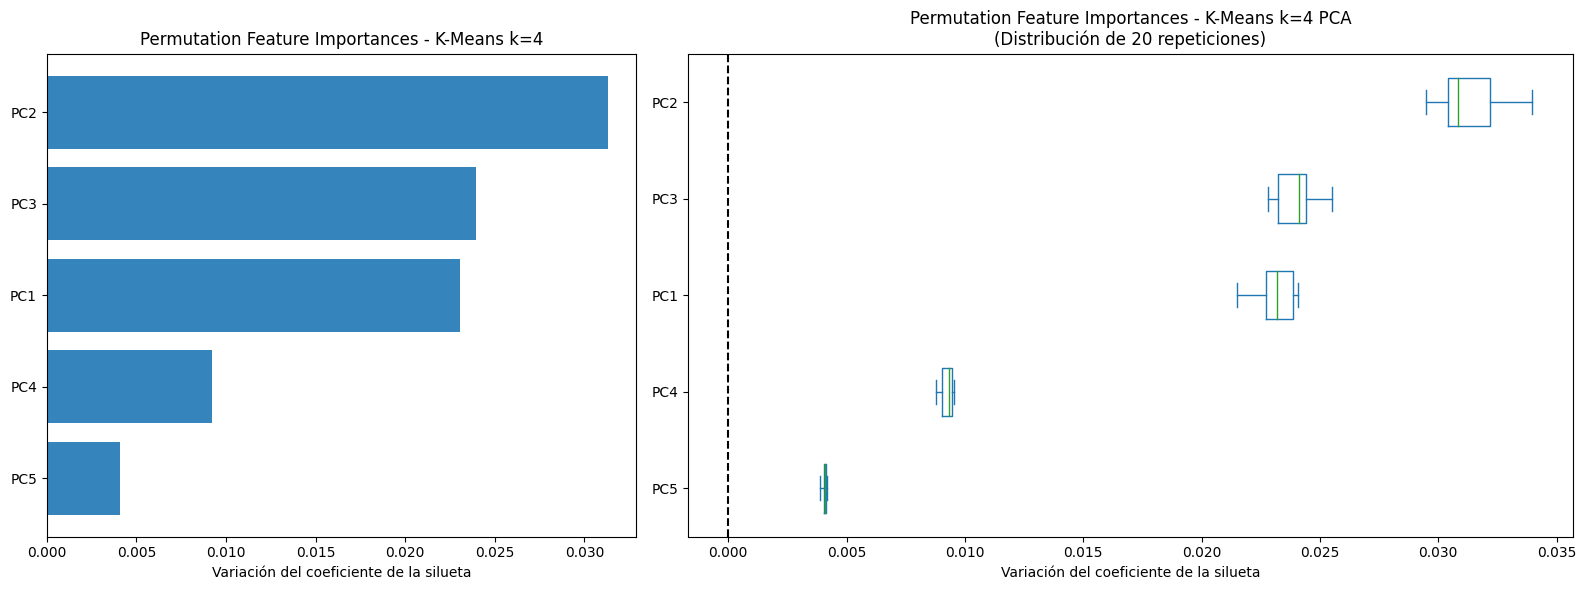

In [6]:
# Extraemos nombres de las features (componentes principales en este caso)
feature_names = X_pca_sample.columns.values

# Ordenación en función de la importancia
sorted_indices_perm = np.argsort(np.abs(p_importance_k4_pca.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Gráfico de barras para mostrar resultados
axs[0].barh(range(len(feature_names)), p_importance_k4_pca.importances_mean[sorted_indices_perm], alpha=0.9)
axs[0].set_yticks(range(len(feature_names)))
axs[0].set_yticklabels(feature_names[sorted_indices_perm])
axs[0].set_title("Permutation Feature Importances - K-Means k=4")
axs[0].set_xlabel("Variación del coeficiente de la silueta")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx = p_importance_k4_pca.importances_mean.argsort()
# Generamos un nuevo df cib todas las repeticiones
importances = pd.DataFrame(
    p_importance_k4_pca.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
# Construimos boxplot de la distribución de importancias de cada variable
importances.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=4 PCA\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

Para interpretar los resultados, se ha considerado que aquella característica (feature) que presente la variación más elevada sobre el coeficiente de *Silhouette* al ser permutada será la más influyente en la formación de los clústeres. En este caso, se ha observado que la característica que más influye es PC2 consiguiendo variar el valor de la silueta en 20 repeticiones del algoritmo un 0.032 aproximadamente. Seguidamente, PC3 y PC1 consiguen variar aproximadamente un 0.020. Por último, las características menos influyentes, es decir, las más próximas a 0 son PC4 y PC5.

Estos resultados han puesto en evidencia que la característica más importante para el modelo K-Means $k=4$ sobre PCA es PC2 que corresponde mayormente, según la calidad de representación (cos2) extraída en el apartado de PCA, a las variables danceability y valence. Esto quiere decir, que la *bailabilidad* y la positividad emocional de una canción son las características que más influyen a la hora de generar los clústeres por parte del algoritmo. Por otro lado, PC3 (mayormente liveness con un 70% de representación) es la siguiente característica que influye en la formación de clústeres junto a PC1 ( representada mayormente por *accousticness* y *energy*). Por último, las características menos importantes en la generación de clústeres PC4 y PC5 corresponden mayormente a la variable tempo. Este hecho ha sugerido que el tempo no es un factor que influya en gran medida a la asignación de los *tracks* a cada clúster. 

### 4.1.3 Cálculo de la importancia de variables para K-Means k=7 sobre PCA

Después de analizar la importancia de las características al permutar las variables de K-Means $k=4$ sobre PCA se ha procedido a realizar el mismo estudio para el modelo K-Means $k=7$ seleccionado como modelo candidato para el sistema de recomendación musical.



In [7]:
# Permutation Feature Importance para K-Means k=7 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_pca.pkl'):
    p_importance_k7_pca = joblib.load('resultados_explicabilidad/p_importance_k7_pca.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_pca = permutation_importance(
        kmeans_k7_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

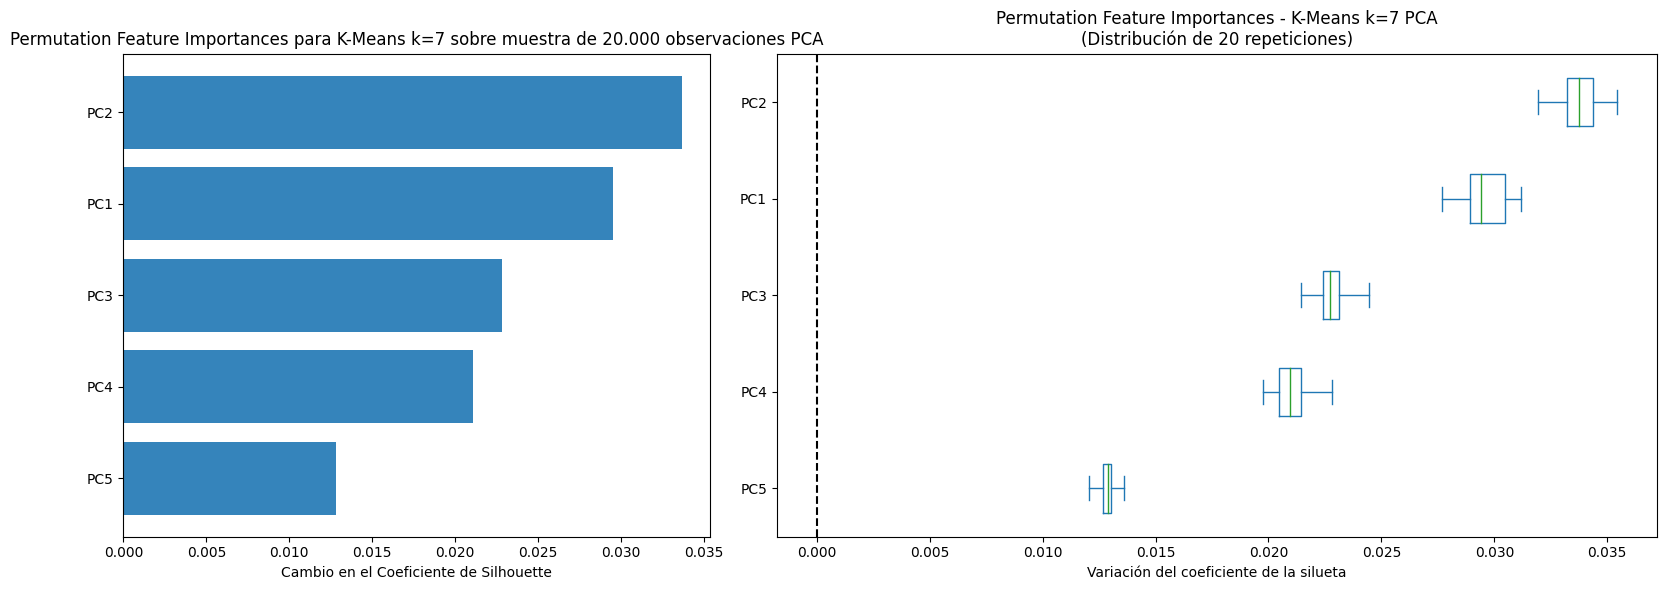

In [8]:
# Nombres de las features (componentes principales)
feature_names_k7 = X_pca_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k7 = np.argsort(np.abs(p_importance_k7_pca.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_k7)), p_importance_k7_pca.importances_mean[sorted_indices_perm_k7], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_k7)))
axs[0].set_yticklabels(feature_names_k7[sorted_indices_perm_k7])
axs[0].set_title("Permutation Feature Importances para K-Means k=7 sobre muestra de 20.000 observaciones PCA")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k7 = p_importance_k7_pca.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k7 = pd.DataFrame(
    p_importance_k7_pca.importances[sorted_importances_idx_k7].T,
    columns=feature_names_k7[sorted_importances_idx_k7],
)
# Construimos el boxplot de la distribución de importancias de cada componente principal
importances_k7.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=7 PCA\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

En términos generales se ha observado que la media de importancia de las variables identificadas como "menos importantes" (PC4 y PC5) para $k=4$ han aumentado casi el doble (de 0.010 y 0.004 a 0.020 y 0.012 respectivamente). Además, la segunda característica más importante en esta ocasión es PC2 que consigue una media de importancia cercana al 0.030. Este último hecho se ha considerado muy importante ya que demuestra que la formación de clústeres está más influenciada por la permutación de accousticness y energy (PC1) que por liveness (PC3). Sin embargo, estos resultados demuestran que a pesar de que hay características que influyen más que otras, todas tienen una mínima influencia e la hora de agrupar las canciones en distintos clústeres. 

### 4.1.4 Cálculo de la importancia de variables para K-Means k=4 sobre el conjunto estandarizado

Después de analizar la importancia de las características sobre los datos PCA, se ha visto que los resultados no muestran de manera clara e interpretable qué variables del conjunto de datos original influyen en la formación de clústeres. Los resultados anteriores, han servido para demostrar como maximizar la calidad del modelo de agrupación pero no ha demostrado ser la mejor herramienta para ganar explicabilidad. A continuación, se procede a realizar el mismo proceso sobre el conjunto de datos estandarizados.

In [9]:
# Muestra representativa para acelerar el cálculo
df_scaled_sample = df_scaled.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_estand.pkl'):
    p_importance_k4_estand = joblib.load('resultados_explicabilidad/p_importance_k4_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k4_estand = permutation_importance(
        kmeans_k4_estand,
        df_scaled_sample,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )


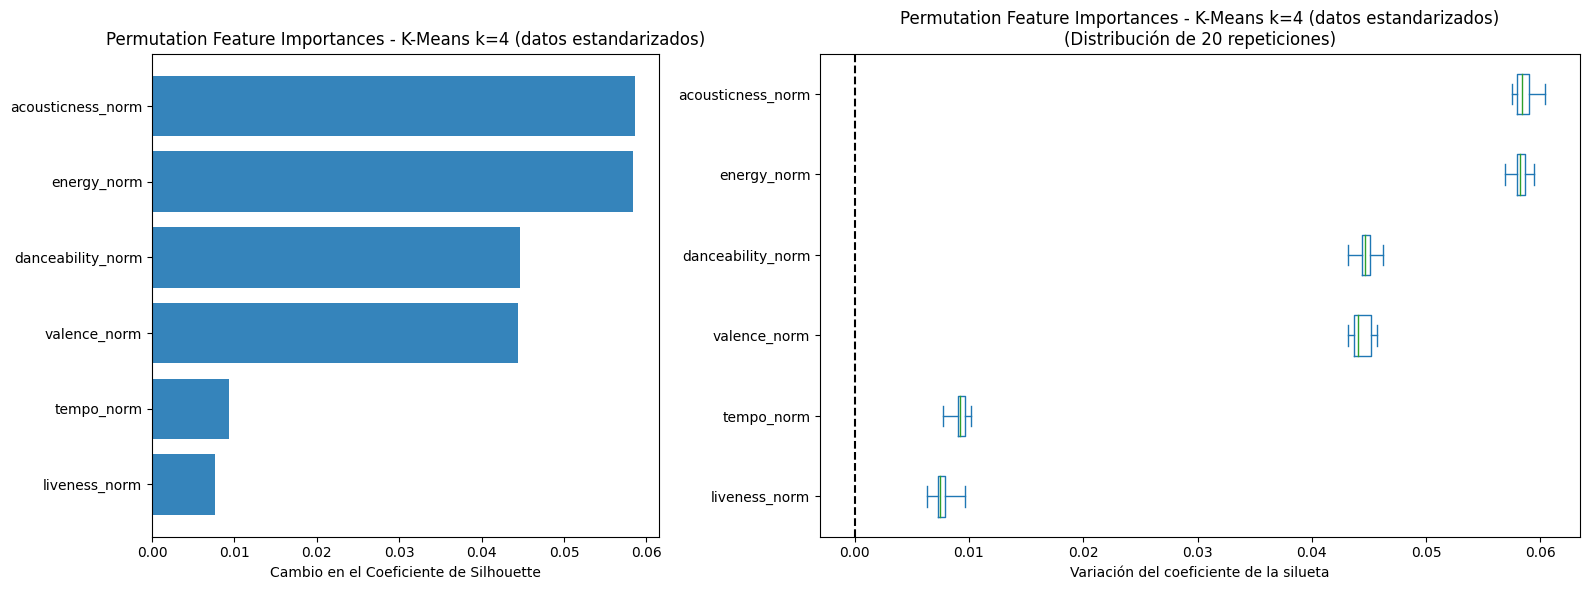

In [10]:
# Nombres de las features (variables estandarizadas)
feature_names_k4_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k4_estand = np.argsort(np.abs(p_importance_k4_estand.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_k4_estand)), p_importance_k4_estand.importances_mean[sorted_indices_perm_k4_estand], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_k4_estand)))
axs[0].set_yticklabels(feature_names_k4_estand[sorted_indices_perm_k4_estand])
axs[0].set_title("Permutation Feature Importances - K-Means k=4 (datos estandarizados)")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k4_estand = p_importance_k4_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k4_estand = pd.DataFrame(
    p_importance_k4_estand.importances[sorted_importances_idx_k4_estand].T,
    columns=feature_names_k4_estand[sorted_importances_idx_k4_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
importances_k4_estand.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=4 (datos estandarizados)\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()


Los resultados han evidenciado que las variables que más influyen a la hora de agrupar observaciones son *acousticness* y *energy* consiguiendo una media de importancia aproximadamente de 0.06 en ambos casos. Seguidamente, con valores de importancia menor (cercanos a 0.045) se tienen las variables *danceability* y *valence*. Por último, se ha demostrado que las dos variables principales *tempo* y *liveness* no son características que importen a la hora de generar los distintos grupos. 

### 4.1.5 Cálculo de la importancia de variables para K-Means k=7 sobre el conjunto estandarizado

Como última aplicación del algoritmo de importancia de características por permutación, se ha extraído la importancia del conjunto de variables sobre K-Means para un valor $K=7$.

In [11]:
# Permutation Feature Importance para K-Means k=7 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_estand.pkl'):
    p_importance_k7_estand = joblib.load('resultados_explicabilidad/p_importance_k7_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_estand = permutation_importance(
        kmeans_k7_estand,
        df_scaled_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

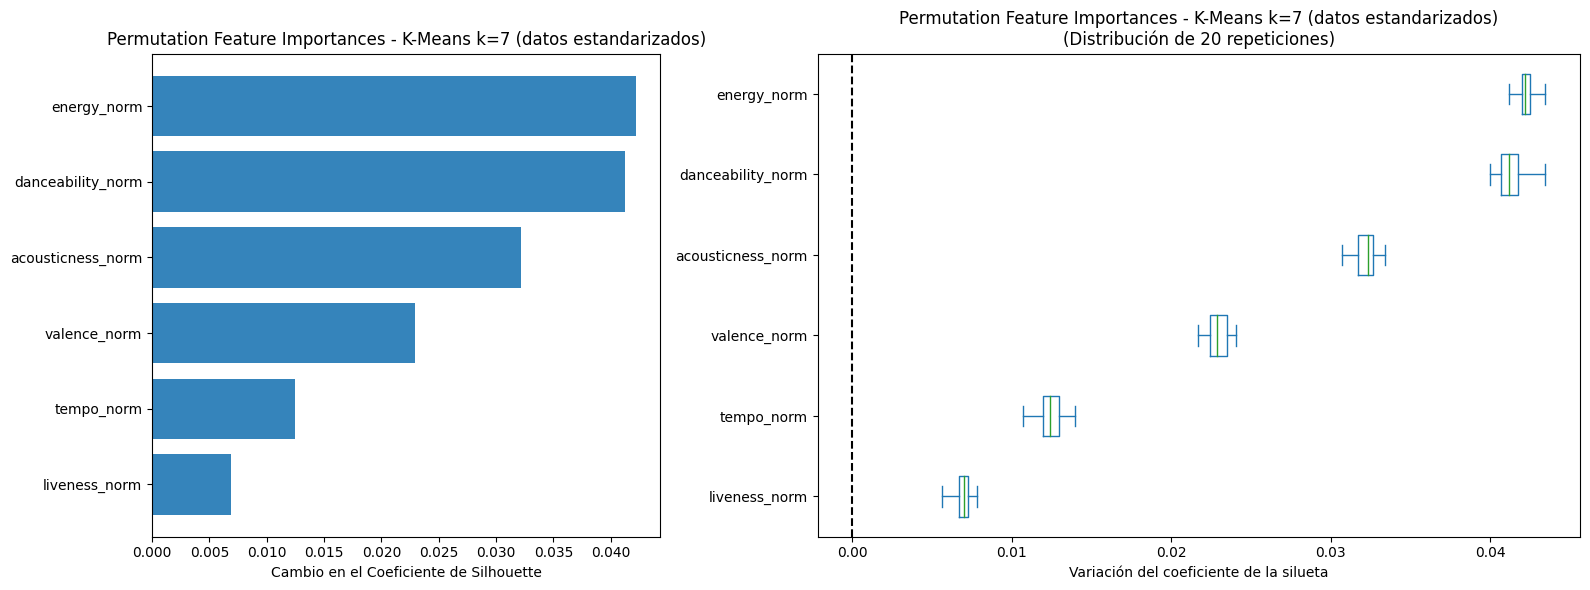

In [12]:
# Nombres de las features (variables estandarizadas)
feature_names_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_estand = np.argsort(np.abs(p_importance_k7_estand.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_estand)), p_importance_k7_estand.importances_mean[sorted_indices_perm_estand], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_estand)))
axs[0].set_yticklabels(feature_names_estand[sorted_indices_perm_estand])
axs[0].set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_estand = p_importance_k7_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_estand = pd.DataFrame(
    p_importance_k7_estand.importances[sorted_importances_idx_estand].T,
    columns=feature_names_estand[sorted_importances_idx_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
importances_estand.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

Se ha podido observar que en este caso el algoritmo PFI sobre el modelo de agrupación K-Means con un valor óptimo de $k=7$ sobre el conjunto de datos original estandarizado ha conseguido identificar que las variables más importantes son *energy* y *danceability*. En este caso, se ha visto que el grado de positividad emocional (valence) de los *tracks* parece ser menos importante que la sonoridad (*accousticness*). Sin embargo, se destaca nuevamente que tanto *tempo* como *liveness* son bastante menos importantes que el resto.

In [13]:
# Guardamos los datos en una carpeta en formato objeto pkl para poder ejecutar el cuaderno con mayor rapidez.
import os
os.makedirs('resultados_explicabilidad', exist_ok=True)

joblib.dump(p_importance_k4_pca, 'resultados_explicabilidad/p_importance_k4_pca.pkl')
joblib.dump(p_importance_k7_pca, 'resultados_explicabilidad/p_importance_k7_pca.pkl')
joblib.dump(p_importance_k4_estand, 'resultados_explicabilidad/p_importance_k4_estand.pkl')
joblib.dump(p_importance_k7_estand, 'resultados_explicabilidad/p_importance_k7_estand.pkl')

['resultados_explicabilidad/p_importance_k7_estand.pkl']

### 4.1.6 Comparación e interpretación de la importancia de variables

Después de analizar las importancias de las características sobre los conjuntos de datos original y PCA, se ha podido observar que PCA no es útil para ganar explicabilidad ya que dificulta la interpretación de los resultados al contar con un espacio de características formado por componentes que representan en distintos porcentajes las variables del conjunto de datos. Sin embargo, se ha visto que sí que es útil para interpretar el modelo en términos de rendimiento cuando se busca maximizar la calidad en la agrupación de los datos.

En definitiva, los resultados obtenidos mediante Permutation Feature Importance han permitido identificar qué características musicales son más determinantes en la formación de los clústeres, proporcionando así una mayor transparencia y comprensión del funcionamiento del modelo de clustering K-Means.

## 4.2 SHapley Additive exPlanations adaptado al clustering (SHAP-C)

### 4.2.1 Introducción y contexto

Tras ver como *Permutation Feature Importance* ha proporcionado una estimación global de la influencia de las distintas características del conjunto de datos en el proceso de agrupamiento, se ha optado por incorporar SHAP, una técnica más avanzada que permite profundizar en la explicabilidad del modelo.

SHAP es una técnica de XAI que permite medir como contribuyen las características de un conjunto de datos sobre los datos de salida de un modelo de aprendizaje automático. Su funcionamiento se basa en la teoría de juegos y los valores de Shapley, donde la salida del modelo se interpreta como el juego y cada variable o característica del conjunto de datos actúa como un jugador que contribuye en mayor o menor medida a la obtención del resultado final del modelo. Así pues, los valores de SHAP cuantifican la magnitud y el sentido de la contribución de cada característica o variable al resultado del modelo con respecto a un valor de referencia (baseline).

A pesar de que SHAP permite explicar la salida de modelos de aprendizaje automático de forma independiente al algoritmo utilizado, cabe señalar que presenta algunas dificultades cuando se aplican en modelos no supervisados ya que, cómo técnica agnóstica al modelo que es, requiere una función de salida del modelo para generar las explicaciones y en clustering no existe una salida como tal. Como se ha comentado anteriormente, las técnicas de clustering carecen de etiquetas ya que su objetivo es agrupar los datos para descubrir patrones ocultos en el conjunto de datos. En consecuencia, al no  existir una *ground truth* que sirva como referencia para medir la contribución de las características a las diferentes agrupaciones que realiza el modelo, se ha considerado modificar el enfoque original para adaptarlo al escenario de este proyecto integrando SHAP-C [50].

Antes de proceder a explicar este nuevo enfoque, merece la pena comprender el funcionamiento base de SHAP mediante la función lineal que la define[50][53]:

$$
 g(z') = \phi_0 + \sum_{j=1}^{M} \phi_j z'_j
$$

donde:

- $g(...)$ es el modelo que devuelve SHAP que contiene las explicaciones.
- $z'$ es el vector de coalición que puede tomar un valor binario donde 0 indica que la característica está ausente en el vector o 1 que está presente.
- $M$ es el tamaño total de características o variables de entrada.
- $\phi_0$ se considera el valor base o esperado que representa la salida del modelo sin tener en cuenta las características. En las interpretaciones de SHAP se le identifica como $E[f(x)]$.
- $\phi_j$ refleja el valor de Shapley para la característica $j$, es decir, su valor de contribución a una predicción concreta generada por el modelo.

En modelos no supervisados al no existir etiquetas ni variables objetivo con lo que comparar, no es posible encontrar un valor esperado ($\phi_0$) con facilidad. Para ello, el nuevo enfoque plantea redefinir la salida del modelo como la distancia euclídea de cada observación al centroide del clúster, a partir de la cual se obtiene un nuevo valor base o esperado ($\phi_0$). [50]:

$$ f'(z') = \frac{1}{|N|} \sum_{p_j \in N} \text{dist}(C_{\text{centroid}}, p_j) \;+\; \sum_{i=1}^{M} \phi_i z'_i $$

donde:

- $f'(z')$ es el modelo SHAP adaptado al *clustering*
- El primer término $\frac{1}{|N|} \sum_{p_j \in N} \text{dist}(C_{\text{centroid}}, p_j)$ corresponde al valor base ($\phi_0$) mencionado anteriormente, calculado como el promedio de distancias euclídeas de todas las observaciones del conjunto de referencia (background) del clúster al centroide
- $N$ es el conjunto de instancias del clúster $C$ (conjunto de referencia o background)
- $|N|$ es el número de instancias en el clúster $C$
- $p_j$ es una observación o instancia perteneciente al clúster $C$
- $C_{\text{centroid}}$ representa el valor del centroide del clúster
- $\text{dist}(C_{\text{centroid}}, p_j)$ es la distancia euclídea entre una observación $p_j$ y el centroide
- El segundo término $\sum_{i=1}^{M} \phi_i z'_i$ representa la contribución de cada característica, donde $\phi_i$ es el valor de Shapley para la característica $i$

Mientras que *Permutation Feature Importance* ha aportado una visión general de la influencia de las variables en el proceso de *clustering*, el enfoque basado en SHAP-C permite analizar la importancia de las características de forma específica para cada clúster, realizando un análisis independiente por clúster. Este enfoque proporciona tanto explicaciones globales (agregando todas las instancias de cada clúster mediante summary plots) como explicaciones locales (para instancias específicas mediante waterfall plots y decision plots).

Así pues, se ha decidido aplicar la técnica de explicabilidad SHAP sobre el modelo K-Means con $k=7$ sobre el conjunto de datos estandarizados, puesto que se ha demostrado anteriormente que realizar el estudio sobre PCA la interpretabilidad de los resultados sigue siendo ambigua. Para no extender la explicación, se ha optado por incorporar las explicaciones de 2 clústeres; para no realizar una selección arbitraria se ha optado por establecer un criterio de selección para escoger el grupo más cohesionado y el más disperso. Cabe mencionar, que se ha escogido un sample de 20.000 observaciones para optimizar el coste computacional del algoritmo SHAP.


### 4.2.2 Visualización de resultados por clúster

In [14]:
def distance_to_centroid_k(X, k):
    """
    Devuelve la distancia euclídea de cada muestra en X al centroide k del modelo kmeans_k7_estand
    """
    centroid_k = kmeans_k7_estand.cluster_centers_[k]
    return np.linalg.norm(X - centroid_k, axis=1)

# Inicialización de la visualización js de SHAP
shap.initjs()
# Obtenemos muestra representativa para explicar el conjunto de datos
sample = df_scaled.sample(n=20000, random_state=42)
# Obtemnemos las etiquetas de clúster del conjunto de datos realizadas en el entrenamiento del modelo
clusters = kmeans_k7_estand.labels_
# Etiquetas de clúster para las muestras que queremos explicar
clusters_explain = kmeans_k7_estand.predict(sample.values)
num_clusters = kmeans_k7_estand.n_clusters

# Diccionarios para guardar resultados por clúster
explainer_by_cluster = {}
shap_values_by_cluster = {}
X_by_cluster = {}

# Para cada clúster entrenamos un explainer
for k in range(num_clusters):
    # Background del explainer que contiene las muestras asignadas al clúster k y definimos un máximo de muestras para no sobrecargar el algoritmo
    cluster_data_k = df_scaled[clusters == k]
    background_k = cluster_data_k.sample(
        n=min(1000, len(cluster_data_k)),
        random_state=42
    )

    # Modelo escalar: distancia al centroide k
    def model_k(X, k=k):
        return distance_to_centroid_k(X, k)

    # Almacenamos el explainer SHAP del clúster k en el diccionario
    explainer_by_cluster[k] = shap.KernelExplainer(model_k, background_k.values)
    # Almacenamos las muestras del clúster k que utilizaremos posteriormente para el método Explainer
    X_by_cluster[k]   = sample[clusters_explain == k]
    # Almacenamos los valores shap del clúster k
    shap_values_by_cluster[k] = explainer_by_cluster[k].shap_values(X_by_cluster[k].values)


c:\Users\marcf\Desktop\UOC\TFG\PEC2\TFG\venv\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1612/1612 [00:11<00:00, 134.59it/s]
Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 4007/4007 [00:30<00:00, 129.69it/s]
Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 2617/2617 [00:20<00:00, 129.69it/s]
Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the backgr

In [15]:
def plot_shap_summary(k):
    """
    Visualiza el summary plot de SHAP para un clúster específico.
    Resumen de la distribución y variación de los valores shap en el cluster k.

    :param k: Número del clúster a visualizar (0 a n_clusters-1).
    """
    # Obtenemos atributos necesarios para generar el gráfico del clúster k (conjunto de datos de k, valores shap de k)
    X_k = X_by_cluster[k]
    shap_k = shap_values_by_cluster[k]

    # Gráfico 1: Resumen de la distribución y variación de los valores shap en el cluster k
    plt.figure()
    shap.summary_plot(shap_k, X_k, show=False)
    plt.title(f'Valores SHAP del clúster {k} \n(num. muestras={len(X_k)})', fontweight='bold', pad=15)
    plt.show()


def plot_instance_waterfall_values(k, instance_id=0):
    """
    Visualiza el waterfall plot de SHAP para una instancia específica.

    :param k: Número identificador del clúster a visualizar.
    :param instance_id: Índice de la instancia a usar en el waterfall plot. Por defecto 0.
    """
    # Obtenemos atributos necesarios para generar el gráfico del clúster k (conjunto de datos de k, valores shap de k y explainer de k)
    X_k = X_by_cluster[k]
    shap_k = shap_values_by_cluster[k]
    explainer_k = explainer_by_cluster[k]
    
    # Gráfico 2: Waterfall plot que muestra la influencia de las características en una instancia
    # Obtenemos los datos de la instancia
    instance_data = X_k.iloc[instance_id].values
    # Obtenemos valores shap de la instancia
    instance_shap_values = shap_k[instance_id]
    # explanation object para el waterfall plot
    explanation_obj = shap.Explanation(values=instance_shap_values, base_values=explainer_k.expected_value, data=instance_data, feature_names=X_k.columns.tolist())
    
    plt.figure()
    shap.plots.waterfall(explanation_obj, show=False)
    plt.title(f'Valores SHAP de la instancia {instance_id} respecto al centroide del clúster {k}', fontweight='bold', pad=15)
    plt.show()

def plot_shap_decision(k, instance_ids=list(range(0))):
    """
    Visualiza el decision plot de SHAP n instancias.
    Muestra cómo cada característica contribuye acumulativamente a la distancia respecto al centroide.

    :param k: Número identificador del clúster a visualizar.
    :param instance_ids: Lista de índices de instancias a visualizar. Si es None, muestra todas.
    """
    # Obtenemos atributos necesarios para generar el gráfico del clúster k (conjunto de datos de k, valores shap de k y explainer de k)
    X_k = X_by_cluster[k]
    shap_k = shap_values_by_cluster[k]
    explainer_k = explainer_by_cluster[k]
    
    # Recogemos los valores shap y los datos de las instancias seleccionadas
    shap_values_plot = shap_k[instance_ids]
    features_plot = X_k.iloc[instance_ids]
    
    # Decision plot
    shap.decision_plot(explainer_k.expected_value,shap_values_plot, features_plot, show=False)
    plt.title(f'Decision Plot del Clúster {k} para un total de {len(instance_ids)} instancias', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()



In [16]:
# Elegiremos 2 clústeres: El más compacto y el más disperso.

cluster_labels = kmeans_k7_estand.labels_

# Obtememos las distancias medias de cada cluster
avg_distances = []

for k in range(kmeans_k7_estand.n_clusters):
    X_k = df_scaled[cluster_labels == k].values
    avg_distances.append(
        np.mean(distance_to_centroid_k(X_k, k))
    )

# Obtenemos la distancia más grande (dispersa) y la más pequeña (compacta)
most_compact_cluster = np.argmin(avg_distances)
most_dispersed_cluster = np.argmax(avg_distances)

print(f"Clúster más compacto: {most_compact_cluster} (distancia promedio={avg_distances[most_compact_cluster]:.2f})")
print(f"Clúster más disperso: {most_dispersed_cluster} (distancia promedio={avg_distances[most_dispersed_cluster]:.2f})")


Clúster más compacto: 1 (distancia promedio=1.35)
Clúster más disperso: 0 (distancia promedio=2.05)


#### 4.2.2.1 Clúster más compacto con distancia promedio de 1.35 (Clúster 1)

Para evaluar los resultados de SHAP, se debe considerar lo siguiente []:

- En el eje X SHAP se representan los valores SHAP, cuánto y en qué sentido una característica contribuye a la salida del modelo. Los valores positivos indican que la característica aumenta la distancia al centroide (aleja la observación del clúster) y, por otro lado, los valores negativos tienden a reducir la distancia al centroide (en este caso acercan la observación al clúster). 
- En el eje Y se dispone las características seleccionadas para estudiar la explicabilidad del modelo. SHAP las ordena en función de su importancia a la hora de contribuir con la salida del modelo.
- Por último, el color de cada punto (*feature value*) indican el valor de la característica, en rojo los valores altos y los bajos en azul. 

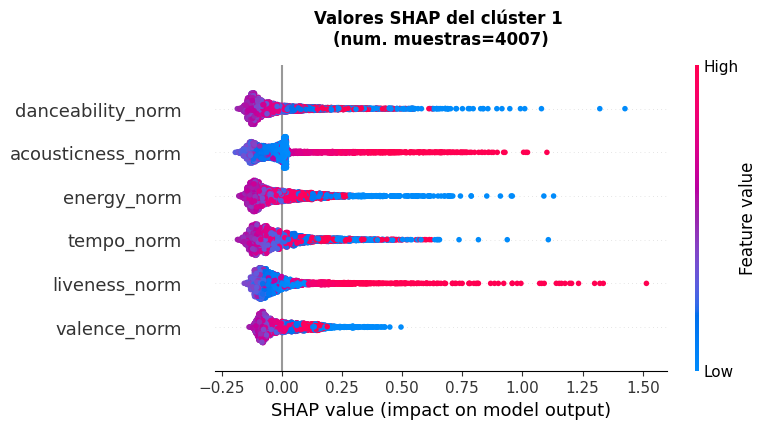

In [17]:
plot_shap_summary(1)

Los resultados de la figura han demostrado que la característica con mayor importancia global dentro del clúste 1 es *danceability* ya que se ubica en la parte superior del eje Y. Además, se ha observado que para valores altos de *acousticness* y *liveness* aumentan la distancia de la observación respecto al centroide del clúster ya que la gran mayoría de estos valores toman valores SHAP positivos mientras que los valores bajos muestran todo lo contrario. Asimismo, los valores bajos de las características *energy* y *valence* tienden también a alejar las observaciones del centroide. Sin embargo, se ha observado que los valores de *danceability* no muestran un patrón claro de separación por colores ya que los puntos rojos (valores altos) y los azules (valores bajos) están distribuidos de manera similar a lo largo del eje X excepto cuando el SHAP para esta característica toma el valor de 0.50 aproximadamente.  

SHAP también ha permitido construir explicaciones locales (sobre una instancia o observación) para visualizar como cada característica contribuye a la distancia de dicha observación respecto al centroide del clúster al que pertenece.

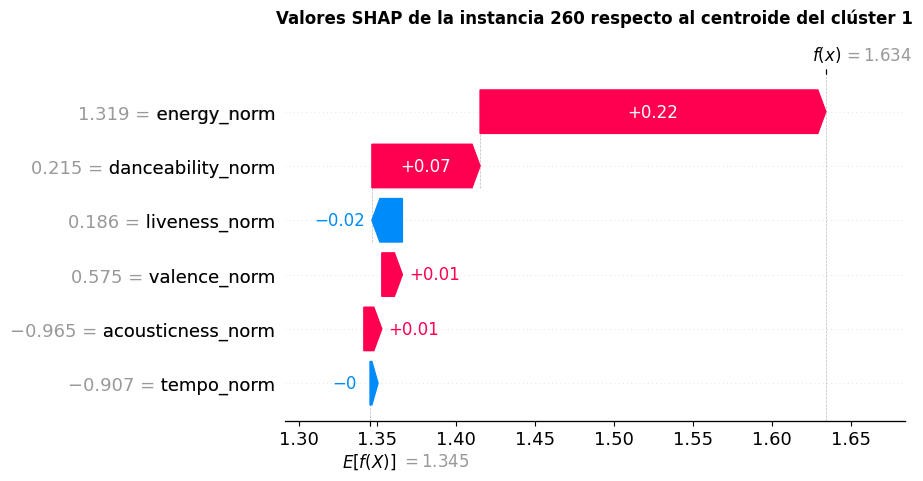

In [18]:
plot_instance_waterfall_values(1, 260)

En la gráfico de la figura , se ha podido visualizar que el valor base o valor esperado $E[F(X)]$ que toma la instancia 260 del clúster 1 es de 1.345. Este valor representa la distancia media de las observaciones del clúster 1 respecto a su centroide, y sirve como punto de referencia a partir del cual se calculan las contribuciones individuales de cada característica. 

Por otro lado, el valor $f(x)$ indica la distancia final de la instancia 260 respecto el centroide del clúster. SHAP obtiene este valor la suma aritmética de las contribuciones asociadas a cada una de las características del conjunto de datos. En este caso, se ha observado que en mayor parte la variable *energy* (+0.22) aleja la instancia 260 del centroide, seguida en menor medida por *danceability* (+0.07). 

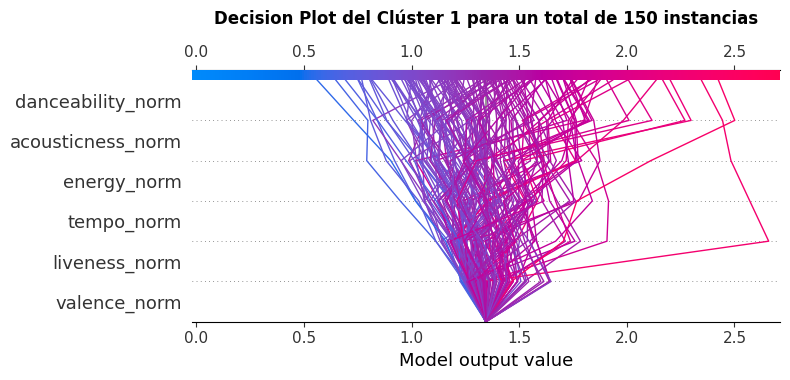

In [19]:
plot_shap_decision(1, list(range(150)))

Otra manera de explicar la salida del modelo es mediante la visualización global del clúster con la ayuda de el uso de gráficos de decisión. Este tipo de gráfico permite reflejar cómo las distintas características de $n$ instancias contribuyen de manera acumulativa a la distancia de estas respecto al centroide del clúster. Cada línea parte del valor base de salida del modelo (1.345 aproximadamente) y se va distribuyendo horizontalmente reflejando cómo contribuye cada característica. 

Las características se disponen en el eje vertical ordenadas según su importancia en la formación del clúster, mientras que en el eje horizontal se representa la distancia acumulada al centroide. El punto final (eje superior) refleja la distancia final de cada instancia respecto al clúster. Los resultados han demostrado que las variables que más influyen a formar el clúster son *danceability*, *accousticness* y *energy*.



#### 4.2.2.2 Clúster menos compacto con distancia promedio de 2.05 (Clúster 0) 

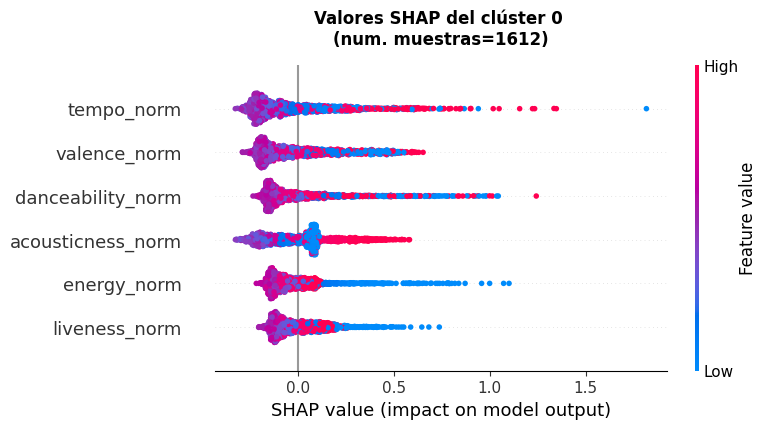

In [20]:
plot_shap_summary(0)

El hecho más destacable que se ha observado es que la característica *tempo* y *valence* pasan a tener más influencia en la formación del clúster 0, lo que indica que cuenta con observaciones donde la positividad emocional y el tempo toman valores más diversos y con mayor variabilidad. En contraste con el clúster 1, donde *danceability*, *acousticness* y *energy* dominan la formación del grupo, el clúster 0 muestra una estructura donde el tempo y la valencia emocional juegan un papel más determinante en la variabilidad de las distancias al centroide.

Por último, cabe señalar que los valores bajos de *energy* y *liveness* (en azul) y, además, los valores altos (en rojo) de *acousticness* fomentan que las observaciones se alejen del centroide. Sin embargo, el resto de variables (*tempo*, *valence* y *danceability*) parecen tomar tanto valores altos como bajos distribuidos a lo largo del rango de valores SHAP, lo que se podría interpretar como que estas características presentan una influencia menos direccional y más variable en la formación del clúster.

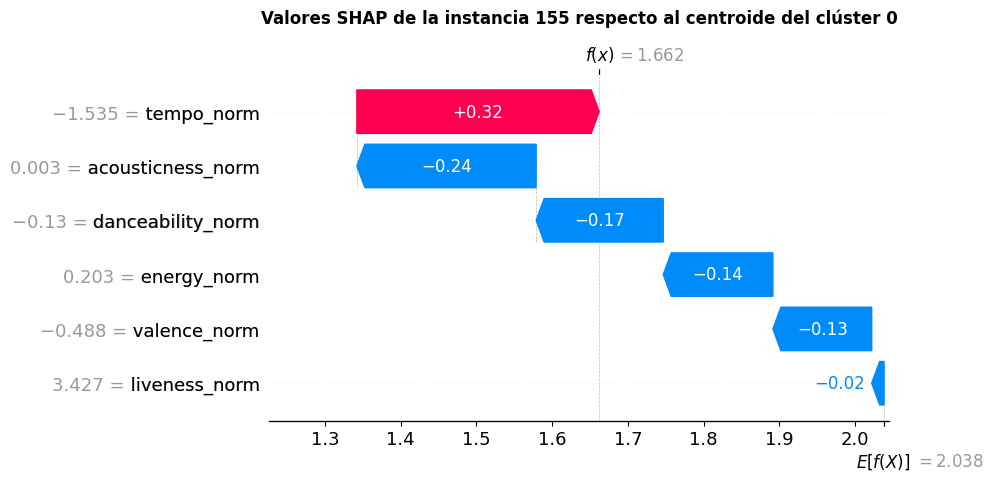

In [21]:
plot_instance_waterfall_values(0, 155)

Después de escoger una instancia al azar del clúster 1, se ha observado que la característica que más aleja dicha instancia del centro del clúster 1 son valores altos de tempo ya que muestran valores positivos altos (+0.32) para dicha característica. Sin embargo, se ha podido visualizar como el resto de características contrarrestan este alejamiento de la instancia respecto al centro al tomar valores SHAPs negativos. 

De hecho, aunque el valor base del clúster es de $[f(x)]=2.038$, la suma de las contribuciones negativas asociadas a *acousticness*, *danceability*, *energy*, *valence* y *liveness* reduce de forma notable el efecto del tempo, dando lugar a un valor final de salida $f(𝑥)=1.662$. Esto indica que, a pesar de que el *tempo* empuja a la instancia a alejarse del centroide, el resto de características contribuyen a que dicha observación se mantenga relativamente cerca.



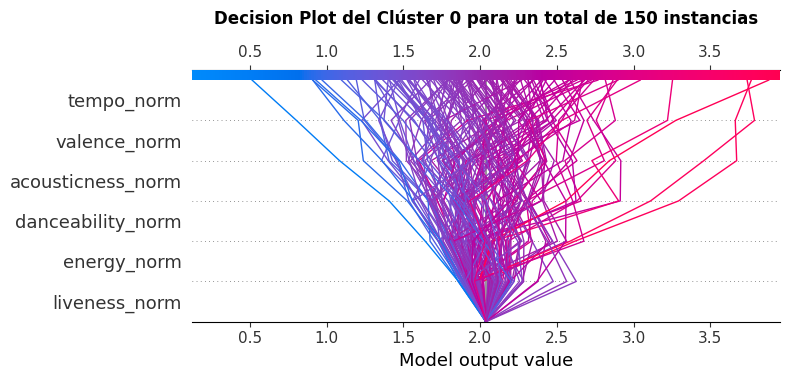

In [22]:
plot_shap_decision(0, list(range(150)))

De manera general, las instancias del clúster 0 muestran un comportamiento heterogéneo donde las variables *tempo* y *valence* generan los mayores despalzamiento de la salida del modelo para dicho grupo. Otro hecho que se ha visualizado, es la presencia de alguna instancia muy distanciada del centro tanto positivamente como negativamente. 

## 4.3 Conclusiones

Antes de implementar las técnicas de XAI, se ha realizado un estudio exhaustivo sobre como enfocar la explicabilidad en modelos no supervisados. Si bien es cierto que la gran mayoría de técnicas están pensadas para explicar modelos supervisados dónde se dispone de una función de salida (función objetivo) o etiquetas, en *clústering* es necesario adaptar estos métodos para utilizar métricas internas y distancias a centroides para explicar cómo y por qué el algoritmo genera los diferentes grupos. 

Si bien es cierto que existen aproximaciones de XAI que transforman un problema no supervisado en un problema supervisado utilizando los *labels* de asignación que genera el modelo de *clústering*. Sin embargo, este enfoque no acaba de ser del todo correcto ya que las etiquetas no representan una verdad fundamental (*ground truth*), si no más bien una decisión interna del algoritmo por lo que utilizarlas para generar explicaciones puede resultar engañoso o poco fiable.

En cuanto a las técnicas utilizadas, por un lado, se ha decidido incorporar *Permutance Feature Importance* como técnica post-hoc agnóstica al modelo para explicar de manera global como influyen las importancias de las características del conjunto de datos en la generación de las agrupaciones del modelo K-Means. Dado que PFI está diseñado originalmente para modelos supervisados, se ha tenido que adaptar el funcionamiento normal para establecer una función de *scoring* mediante el criterio de la silueta que ha permitido evaluar el rendimiento del modelo en 20 repeticiones. Esta adaptación se ha aplicado sobre diferentes configuraciones del modelo (K-Means con $k=4$ y $k=7$, tanto sobre datos PCA como estandarizados), utilizando una muestra representativa de 20.000 observaciones para optimizar el coste computacional. Los resultados han permitido identificar que, sobre el conjunto de datos estandarizados, las características más determinantes en la formación de clústeres son *energy*, *danceability*, *acousticness* y *valence*, mientras que *tempo* y *liveness* presentan una influencia menor en el proceso de agrupación.

Por otro lado, se ha incorporado otro enfoque de XAI basado en SHAP adaptado al contexto de clustering (SHAP-C [50]), con el objetivo de disponer de una herramienta que permita analizar la contribución de las características tanto a nivel global como local dentro de cada clúster. Para llevar a cabo esta tarea se ha decidido seleccionar únicamente K-Means con $k=7$ sobre el conjunto de datos estandarizados ya que se ha demostrado en la aplicación de PFI que utilizar el conjunto PCA no consigue otorgar explicaciones claras e interpretables sobre como el modelo toma los datos en cuestión de agrupamiento de datos. Sin embargo, debido a los resultados obtenidos, se ha considerado que el uso de PCA si que resulta interesante cuando se pretende mejorar el rendimiento del sistema de recomendación musical ya que permite identificar los componentes que más influyen en la formación de los distintos clústeres.

SHAP ha permitido extraer información interesante sobre las características que más contribuyen a la formación de los diferentes clústeres por parte de K-Means. Se ha decidido escoger dos clústeres según su grado de cohesión interna (el más compacto con distancia promedio de 1.35 y el más disperso con distancia promedio de 2.05) con el objetivo de no extender el análisis. Así pues, se ha visto que el clúster más compacto (clúster 1) presenta una estructura donde *danceability*, *acousticness* y *energy* dominan la formación del grupo, mientras que el clúster más disperso (clúster 0) muestra que *tempo* y *valence* tienen una influencia más determinante en la variabilidad de las distancias al centroide.Estas diferencias en las características dominantes entre clústeres con distintos grados de cohesión proporcionan una visión más profunda sobre cómo las diferentes propiedades musicales contribuyen de forma heterogénea a la formación de agrupaciones, complementando así la explicabilidad global obtenida mediante PFI con explicaciones locales y específicas por clúster.


# 5. Cuantificación de la Incertidumbre (UQ)


## 3.4.4 Gaussian Mixture Model (GMM)



Gaussian Mixture Model (GMM) es un modelo probabilístico en el que se considera que las observaciones se generan a partir de una combinación de un número finito de distribuciones gaussianas con parámetros desconocidos. Se considera que es una generalización de K-means a diferencia de que GMM no asigna cada observación a un único clúster sino que obtiene una distribución de probabilidad de pertenencia de dicha observación a cada clúster.

**El algoritmo K-means considera que sus clústeres son esféricos y con una densidad similar, sin embargo, la capacidad de GMM de asignar una probabilidad a cada observación permite generar agrupaciones con múltiples formas.** 

Para entender este enfoque se retomará el gráfico de K-means para $k=7$ sobre el conjunto de PCA:


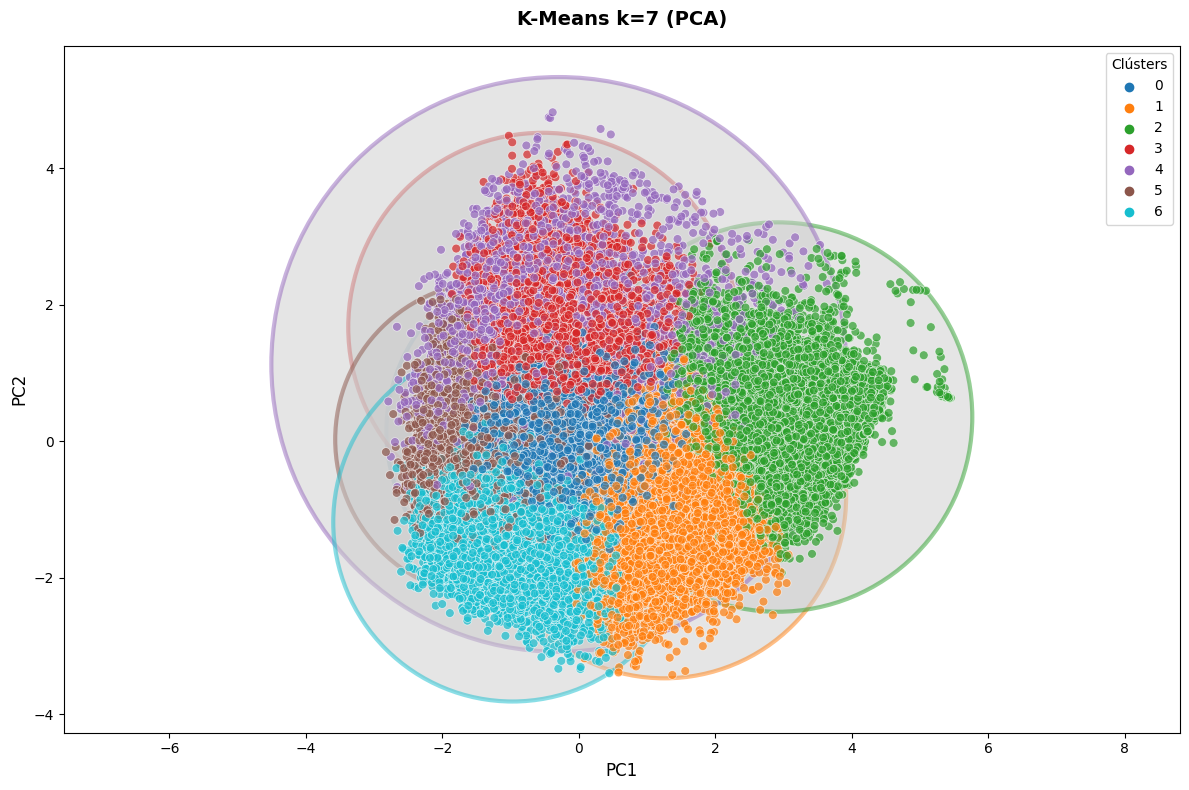

In [35]:
labels = kmeans_k7_pca.fit_predict(X_pca)

df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Clústers': labels
})

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('equal')

clusters = sorted(np.unique(labels))
palette_k7 = palette_colors[:len(clusters)]  # Cambiar nombre a palette_k7 para claridad

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Clústers', 
                hue_order=clusters, palette=palette_k7, s=40, alpha=0.7, ax=ax, zorder=2, legend=True)

centers = kmeans_k7_pca.cluster_centers_  # Cambiar a kmeans_k7_pca
# proyectamos centros y puntos a 2D antes de calcular distancias con cdist
centers_2d = centers[:, :2]
X_pca_2d = X_pca[:, :2] 

# Calcumamo radios solo en el espacio 2D
radii = [cdist(X_pca_2d[labels == i], [center_2d]).max()
         for i, center_2d in enumerate(centers_2d)]

# Dibujamos círculos con los colores correspondientes de la paleta de colores utilizada hasta ahora
for idx in range(len(centers_2d)):
    c_2d = centers_2d[idx]
    r = radii[idx]
    cluster_idx = clusters[idx]
    color = palette_k7[idx]
    ax.add_patch(plt.Circle(c_2d, r, fc='#CCCCCC', ec=color, lw=3, alpha=0.5, zorder=1))

ax.set_title('K-Means k=7 (PCA)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)


plt.tight_layout()
plt.show()

Tal y como se ha comentado en el apartado donde se trata k-mean, el **solapamiento de clústeres impide que el algoritmo decida de forma determinista si una muestra pertenece a un clúster u otro**. En la figura anterior se observa que, aunque algunos puntos quedan claramente dentro de un único clúster, la mayoría de los puntos se encuentran en regiones donde los círculos de dos o más clústeres se superponen. Este solapamiento evidencia que k-means asigna cada punto a un clúster sin considerar la incertidumbre inherente a los puntos situados en las zonas de trawnsición entre clústeres. Esta limitación podría llevar al sistema de recomendación musical a realizar asignaciones rígidas que no reflejen la naturaleza ambigua de las canciones con características intermedias, es decir, situadas en las transiciones entre grupos, lo que perjudica la capacidad de exploración de la diversidad musical.

Para tratar de solventar este problema y con el fin de obtener otra perspectiva, se decide incorporar una versión ligera del algoritmo GMM. Este modelo, permitirá definir para cada observación la probabilidad de pertenecer a un grupo u a otro.

#### 3.4.4.1 Selección del número de componentes y el tipo de matriz de covarianza

Para utilizar el modelo GMM de scikit-learn de deberá definir el número de componentes asi como el tipo de matriz de covarianza que se utilizará:

- Matriz esférica: Cada componente tiene su propia varianza, pero todas las dimensiones comparten la misma varianza.
- Matriz diagonal: Cada componente tiene su propia matriz de covarianza diagonal, permitiendo que cada dimensión tenga su propia varianza.
- Matriz compartida: Todos los componentes comparten la misma matriz de covarianza, pero cada componente tiene su propia media
- Matriz completa: Cada componente tiene su propia matriz de covarianza completa sin restricciones.

Para determinar el número óptimo de componentes así como el tipo de matriz de covarianza, se utilizará el criterio Bayasian Information Criterion (BIC) con el objetivo de visualizar cómo de bien se ajustan los datos observados al modelo a la vez que se controla el overfitting [41, *véase bibliografía del TFG*].

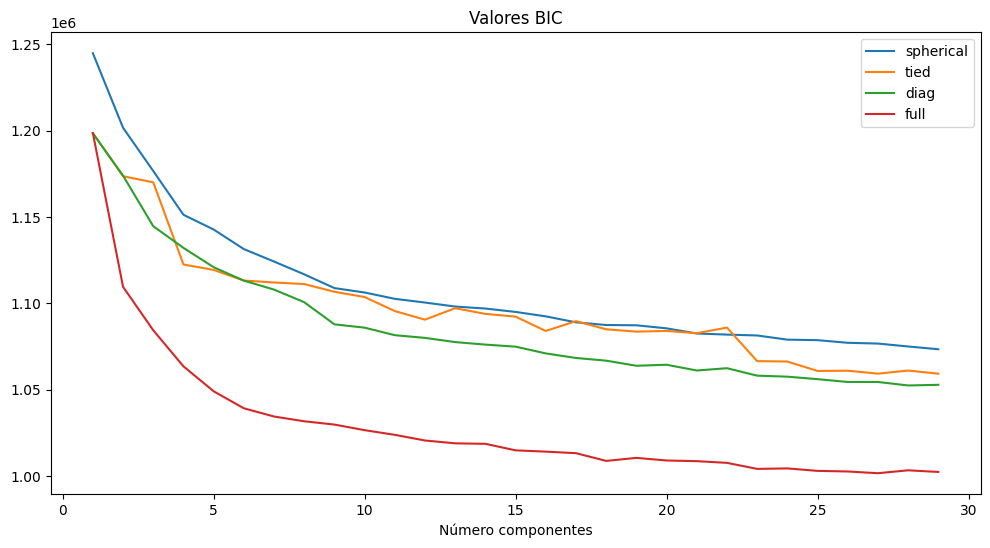

In [36]:
from sklearn.mixture import GaussianMixture

fig, ax = plt.subplots(figsize=(12, 6))
# Definimos un rango de componentes para entrenar el modelo
n_components = range(1, 30)
c_types = ['spherical', 'tied', 'diag', 'full']

# Para cada tipo de matriz de covarianza  entrenamos el modelo con 1 hasta 30. Esta función puede volverse lenta debido al coste computacional.
for c_type in c_types:
    valores_bic = []
    
    for i in n_components:
        gmm = GaussianMixture(n_components=i, covariance_type=c_type)
        modgmmelo = gmm.fit(X_pca)
        #En este punto extraemos el valor bic de cada modelo y lo añadimos a la lista
        valores_bic.append(gmm.bic(X_pca))
        
    sns.lineplot(x=n_components, y=valores_bic, label=c_type, ax=ax)
        
ax.set_title("Valores BIC")
ax.set_xlabel("Número componentes")
ax.legend()
plt.show()

#### 3.4.4.2 Entrenamiento del modelo con 20 componentes

Para determinar el número de componentes y el tipo de covarianza, se deberá elegir el número con valor más bajo, en este caso **20 aproximadamente y el tipo de matriz "full**".

In [37]:
gmm_pca = GaussianMixture(n_components = 20, covariance_type = 'full', random_state = 42)

gmm_pca.fit(X_pca)

GaussianMixture(n_components=20, random_state=42)

A continuación, se realiza una predicción sobre el conjunto de datos PCA con el objetivo de visualizar como el algoritmo Gaussian Mixture genera los grupos.

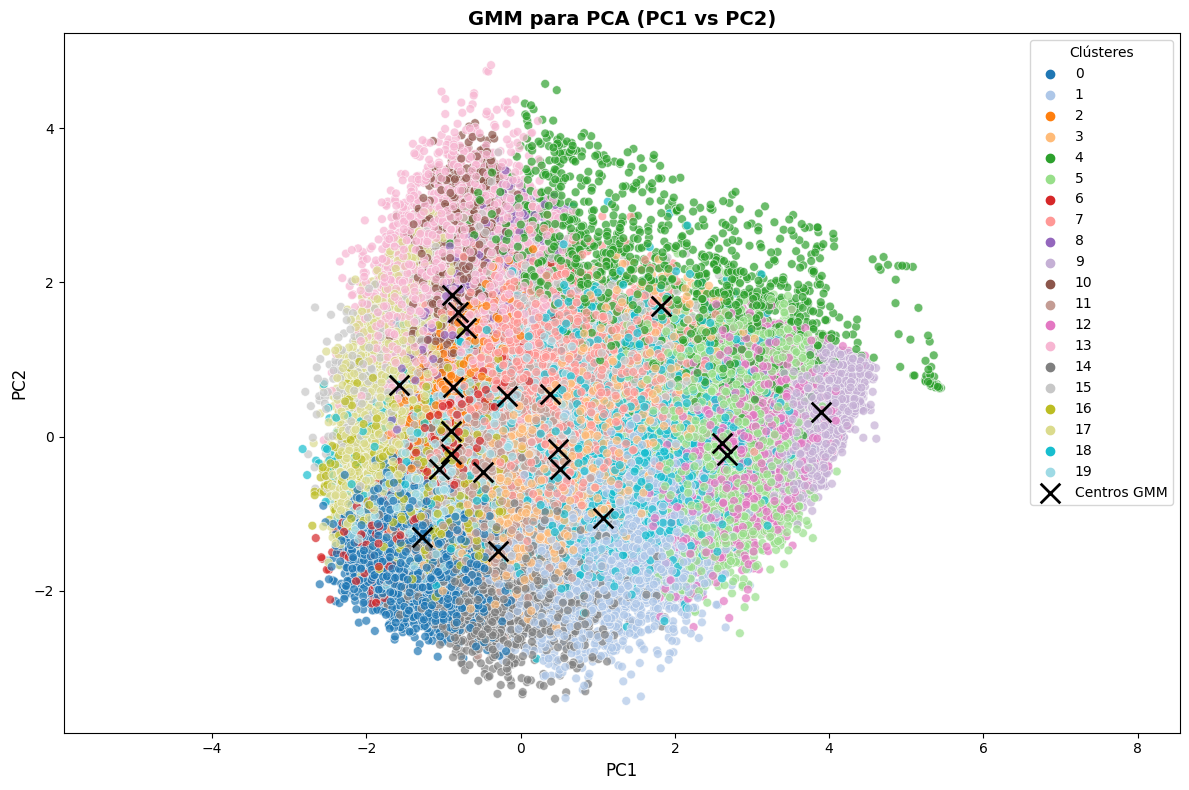

In [38]:
labels_gmm = gmm_pca.predict(X_pca)

clusters = sorted(np.unique(labels_gmm))

# Crear DataFrame con la columna de clústeres para que seaborn use el nombre como título
df_plot = X_pca_df.copy()
df_plot['Clústeres'] = labels_gmm

s = 40
a = 0.7

plt.figure(figsize=(12, 8))
plt.axis('equal')

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Clústeres', hue_order=clusters, s=s, alpha=a, palette='tab20', zorder=2, legend=True)

# Se obtienen los centros de cada clúster en base a los datos de PC1 y PC2
centers_2d = gmm_pca.means_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', marker='x', s=200, linewidths=2, label='Centros GMM', zorder=3)

plt.title('GMM para PCA (PC1 vs PC2)', fontsize=14, fontweight='bold')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend(title='Clústeres', loc='upper right')
plt.tight_layout()
plt.show()

El hecho más evidente es que se observa un elevado solapamiento entre clústeres. Sin embargo, tal y como se ha comentado en el análisis de K-means, este fenómeno no se considera necesariamente como un aspecto negativo, ya que los las canciones pueden tomar diversas características en un marco amplio aún siendo del mismo género. **Así pues, el solapamiento puede resultar incluso beneficioso para encontrar canciones de otros géneros que compartan las mismas características musicales**.

#### 3.4.4.3 Evaluación probabilística de asignaciones: certeza e incertidumbre

En este punto se procede a visualizar la probabilidad de asignaciones de canciones a los grupos generawdos por el algoritmo:

In [39]:
# Se obtienen las probabilidades de pertenencia a cada clúster mediante el método predict_proba
probs = gmm_pca.predict_proba(X_pca)
print(probs[:5].round(3))

[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.003 0.13  0.006 0.    0.    0.211 0.65 ]
 [0.    0.025 0.    0.003 0.001 0.429 0.    0.003 0.    0.014 0.    0.
  0.52  0.    0.    0.    0.    0.    0.003 0.   ]
 [0.    0.013 0.    0.798 0.002 0.    0.    0.182 0.    0.    0.    0.001
  0.002 0.    0.    0.    0.    0.    0.001 0.   ]
 [0.    0.004 0.    0.    0.002 0.985 0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.009 0.   ]
 [0.    0.177 0.    0.    0.    0.    0.    0.789 0.    0.    0.    0.021
  0.    0.    0.    0.    0.    0.    0.011 0.   ]]


Tal y como se observa, el método devuelve una matriz (n_samples , n_clusters) con los valores de medida sobre la probabilidad de que cualquier punto pertenezca al clúster dado. Para visualizar mejor este hecho, se procede a generar un histograma:

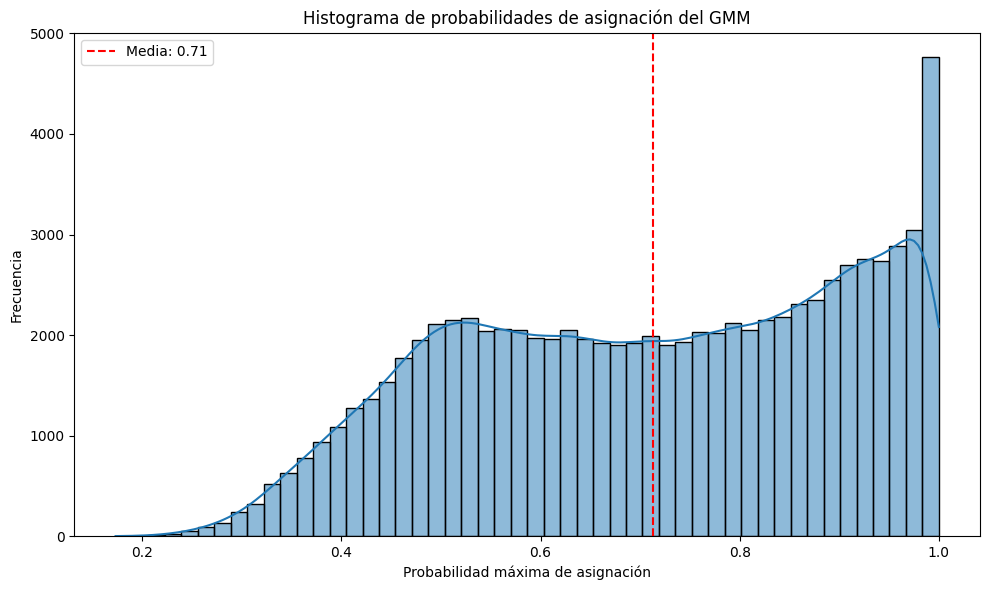

In [40]:
# Calculamos la probabilidad máxima de cada observación para determinar la certeza de asignación a los clústeres
probs_max = probs.max(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(probs_max, bins=50, kde=True)
plt.xlabel('Probabilidad máxima de asignación')
plt.ylabel('Frecuencia')
plt.title('Histograma de probabilidades de asignación del GMM')
plt.axvline(probs_max.mean(), color='r', linestyle='--', label=f'Media: {probs_max.mean():.2f}')

plt.legend()
plt.tight_layout()
plt.show()

En el histograma de probabilidades de asignación del GMM se observa lo siguiente:

- Se tiene aproximadamente 5000 observaciones con una asignación clara (probabilidad máxima próxima a 1.0), lo que indica que estas canciones presentan características musicales bien definidas que las sitúan claramente dentro de un único clúster.

- Entre 0.5 y 0.85 se observa un número elevado de canciones que podrían pertenecer a más de un clúster. De esta observación se puede concluir que el modelo no logra separar bien las asignaciones de las canciones a los clústeres por lo que que hay zonas de solapamiento en el que las canciones comparten características musicales.

- Existe un número menor de observaciones que el algoritmo tiene serias dificultades para asignarlas a un grupo (0.2 - 0.49), lo que podría indicar canciones con perfiles musicalmente atípicos o que combinan elementos de múltiples géneros de manera equilibrada.

- La media de probabilidad máxima de 0.71 indica que el modelo presenta una certeza razonable en la mayoría de las asignaciones. Sin embargo, el elevado número de canciones con certeza moderada, evidencia que el epsacio muscal presenta zonas de solapamiento significativa lo cual resulta beneficioso para un sistema de recomendación musical orientado a ampliar la exploración musical.


A continuación, se procede a visualizar 10 canciones que el algoritmo clasifica con una probabilidad del 100% a un clúster en concreto: 


In [41]:
# Canciones con asignación de alta certeza (probabilidad máxima >= 0.99)
high_confidence_threshold = 0.99
high_confidence_songs = probs_max >= high_confidence_threshold

# Extraemos canciones con probabilidad de asignación muy alta
df_high_confidence_songs = df.loc[X_pca_df.index[high_confidence_songs]].copy()
df_high_confidence_songs['cluster_gmm'] = labels_gmm[high_confidence_songs]
df_high_confidence_songs['probs_max'] = probs_max[high_confidence_songs]

print(f'Canciones con alta certeza (≥{high_confidence_threshold}): {high_confidence_songs.sum()}')

display(df_high_confidence_songs.sort_values('probs_max', ascending=False).head(10))

Canciones con alta certeza (≥0.99): 3451


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_genre,popularity_bin,energy_norm,acousticness_norm,danceability_norm,valence_norm,tempo_norm,liveness_norm,cluster_gmm,probs_max
28864,0DncYlZZcfFn49R37ehVit,Los Perlas,Mi Chile Lindo,Chicha de Curacaví,42,178800,False,0.650,0.673,4,...,folk,Poco popular,0.144380,1.496347,0.509048,1.791128,0.027230,3.872887,15,1.0
70572,0LQWDzZ89sg3EzJxXoo5tu,Fania All Stars;Celia Cruz;Ismael Rivera,Live (Live At The Roberto Clemente Coliseum / ...,Cúcala - Live,27,420414,False,0.586,0.780,2,...,salsa,Poco popular,0.559194,1.287289,0.147096,1.745541,-0.254014,3.898208,15,1.0
71178,0jM5ETGLOnVbCrnXafOjMa,Samba De Raiz,"Samba de Raiz - Ao Vivo, Vol. 2",É Preciso Muito Amor - Ao Vivo,35,197200,False,0.543,0.682,11,...,samba,Poco popular,0.179271,1.198954,-0.096091,1.730346,-0.124686,3.847566,15,1.0
78993,5cOAbX7oBPRdmSaHB5FusN,Julio Sosa,Mejores Exitos,Canchero,21,150047,False,0.501,0.694,1,...,tango,Escasa popularidad,0.225792,1.908575,-0.333622,1.312465,-0.207773,3.680447,15,1.0
79327,2IlLA49nNVHNCqR3sUNvW0,Roberto Goyeneche,La Última Curda,Contramarca,19,141154,False,0.645,0.585,0,...,tango,Escasa popularidad,-0.196776,1.549348,0.480770,1.696155,0.210761,3.771603,15,1.0
71063,3jAy3gMSprXBZzrZMe1ufO,Arlindo Cruz,Batuques do Meu Lugar (Ao Vivo),Testamento de Partideiro - Ao Vivo,37,150213,False,0.540,0.677,2,...,samba,Poco popular,0.159887,1.319678,-0.113057,1.817721,-0.593325,3.852630,15,1.0
71050,4YwjGd3CwzBiuulNuzcNff,Zeca Pagodinho,Zeca Pagodinho - Uma Prova De Amor Ao Vivo (De...,Coração Em Desalinho - Ao Vivo,37,171160,False,0.507,0.818,1,...,samba,Poco popular,0.706511,1.399179,-0.299689,1.126318,0.209628,3.832373,15,1.0
59922,5OA7hefkKNCxb1qJ8UA2xR,Thiago Martins,A Gente Combina,A Gente Combina,47,214972,False,0.517,0.805,11,...,pagode,Poco popular,0.656113,1.213677,-0.243134,1.547998,1.794846,3.791860,15,1.0
6418,1xbU7iGd2rXLBgEYF4xlkf,The Kentucky Colonels,Long Journey Home,Listen To The Mockingbird,23,73000,False,0.440,0.686,2,...,bluegrass,Escasa popularidad,0.194778,1.246066,-0.678607,1.829117,-0.431782,3.801988,15,1.0
71040,3yTRxKoTqRfvU1vrsGMjYx,Xande De Pilares,Nos Braços Do Povo (Ao Vivo / Vol.2),Coração Radiante - Ao Vivo,37,151263,False,0.574,0.754,0,...,samba,Poco popular,0.458398,1.378568,0.079230,1.840514,-0.806706,3.852630,15,1.0


Llegados a este punto, se procede a visualizar 10 canciones para un umbral comprendido entre 0.5 y 0.7 de probabilidad de asignación.

In [42]:
# Canciones con baja certeza (probabilidad máxima <= 0.5) - canciones intermedias

low_confidence_songs = (probs_max <= 0.7) & (probs_max >= 0.5)

# Extraemos canciones con probabilidad de asignación baja (mayor ambigüedad)
df_low_confidence_songs = df.loc[X_pca_df.index[low_confidence_songs]].copy()
df_low_confidence_songs['cluster_gmm'] = labels_gmm[low_confidence_songs]
df_low_confidence_songs['probs_max'] = probs_max[low_confidence_songs]

print('\nLas 10 canciones con menor probabilidad máxima entorno al 0.5 (mayor ambigüedad):')

display(df_low_confidence_songs.sort_values('probs_max', ascending=True).head(10))



Las 10 canciones con menor probabilidad máxima entorno al 0.5 (mayor ambigüedad):


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_genre,popularity_bin,energy_norm,acousticness_norm,danceability_norm,valence_norm,tempo_norm,liveness_norm,cluster_gmm,probs_max
1449,3cYQvXCTPcolOTsDSTfV0j,Jackie Mittoo,Keyboard King at Studio One,Henry the Great,20,212493,False,0.937,0.500,7,...,afrobeat,Escasa popularidad,-0.526301,0.633613,2.132176,0.932574,-0.684774,-0.583637,1,0.500003
70033,7A0CC1rU4kSHGz5AMDKBD1,Mr Black El Presidente,Borracha (Versión Champeta),Borracha - Versión Champeta,33,221269,False,0.546,0.562,7,...,salsa,Poco popular,-0.285942,-0.308622,-0.079124,1.198498,-1.182064,-0.693531,3,0.500012
13552,35pv1iC2KwjKOGogg3UJEm,Finding Hope,wish u felt the way i do,wish u felt the way i do,58,121500,False,0.723,0.304,10,...,chill,Popular,-1.286148,1.222510,0.921899,-0.738948,-1.406339,-0.568444,1,0.500012
76099,0OA3CYWsAa2iblrLH24qVO,Cristian,Agua Nueva,"Señora, Por Favor",27,231173,False,0.689,0.811,9,...,spanish,Poco popular,0.679374,-0.872785,0.729612,0.324747,-0.079311,-0.777090,11,0.500019
23862,5WqHQvyyZVJtOMW9vyqTGT,Teebee,TeeBee Archives,Let Go,17,373274,False,0.517,0.973,6,...,drum-and-bass,Escasa popularidad,1.307411,-0.968035,-0.243134,0.203182,1.761132,-0.956364,17,0.500026
52700,0ZcF74nIV5GJi1selp9nVl,Mark D. Pencil,Fun Exercise Songs!,Stand in Place and Move,8,182920,False,0.768,0.784,6,...,kids,Escasa popularidad,0.574701,-0.840396,1.176397,-1.297389,0.424975,0.748256,19,0.500028
67807,5FUxnxo1B3IPUGA1kT0yGs,Eduardo Araujo;The Fevers,Bis Jovem Guarda,O Bom,31,163373,False,0.684,0.789,9,...,rockabilly,Poco popular,0.594085,-0.055396,0.701335,1.737943,0.655480,-0.751769,0,0.500029
30518,7bq1UByhd0fUN4zOZcAquH,Renaud,Boucan d'enfer,Baltique,33,176493,False,0.533,0.313,0,...,french,Poco popular,-1.251257,1.181287,-0.152646,0.024633,-0.925474,-0.406389,12,0.500031
30358,0BKzMLvouXW9khQeFiOOTz,MR TOUT LE MONDE,For Real,For Real,55,181732,False,0.421,0.724,2,...,french,Popular,0.342095,-0.916658,-0.786062,-0.773139,1.924674,-0.188627,7,0.500032
36033,53f60feUUi4ofcJWRiNCm5,Novo Som;Catedral,Mais Que Amigos = Irmãos (Ao Vivo),Acredita - Ao Vivo,23,422706,False,0.313,0.519,11,...,groove,Escasa popularidad,-0.452643,0.795560,-1.396856,-1.107443,0.356380,0.743192,18,0.500057


Y, por último, se procede a generar un gráfico para observar la incertidumbre en las asignaciones del modelo GMM:

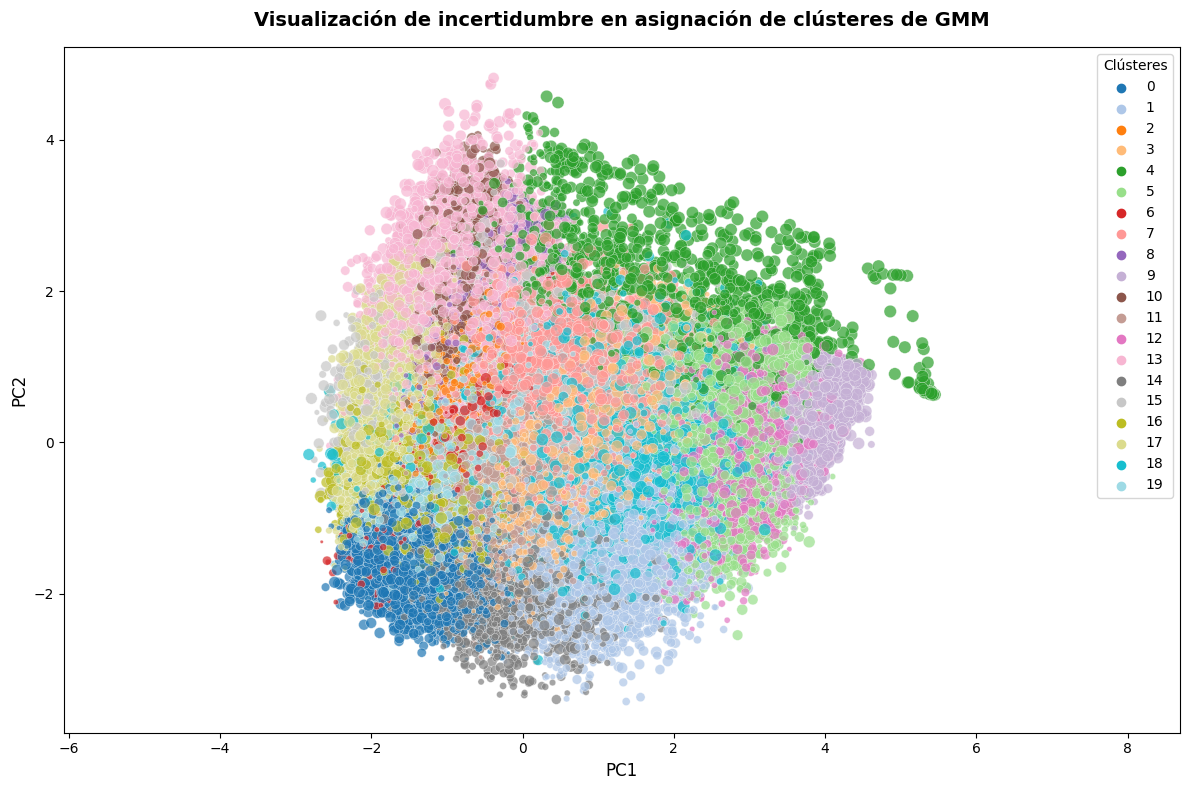

In [43]:

# El tamaño de los puntos será proporcional a la certeza de asignación. Contra más grande sea el valor más grande se verá el punto
size = 80 * probs_max ** 2
df_plot = X_pca_df.copy()
df_plot['cluster'] = labels_gmm

clusters = sorted(np.unique(labels_gmm))

plt.figure(figsize=(12, 8))
plt.axis('equal')
# Visualización de los clústeres donde el tamaño de cada punto es proporcional a la certeza de su asignación
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='cluster',hue_order=clusters, s=size, alpha=a, palette='tab20', zorder=2)

plt.title('Visualización de incertidumbre en asignación de clústeres de GMM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend(title='Clústeres', loc='upper right')
plt.tight_layout()
plt.show()

#### 3.4.4.4 Evaluación del modelo GMM mediante métricas de validación interna

Y como punto final, se procede a visualizar el rendimiento del modelo:

In [44]:

# Calculamos métricas de calidad de gmm con 20 componentes
metrics_gmm_20 = compute_cluster_metrics(X_pca, labels_gmm)

metrics = pd.DataFrame(
    [metrics_gmm_20],
    index=['GMM (n_components=20, todas las PCs)']
)

display(metrics)


,Silhouette,Davies_Bouldin,Calinski_Harabasz
"GMM (n_components=20, todas las PCs)",0.04,1.75,7788.0


Las métricas de validación interna del modelo GMM con 20 componentes (Silhouette = 0.04, Davies-Bouldin = 1.75, Calinski-Harabasz = 7788) muestran valores inferiores a los obtenidos con K-Means, lo que refleja el mayor solapamiento generado es mayor.

El análisis del entrenamiento de GMM se ha realizado para un número de componentes igual a 20 confiando en los resultados que ha ofrecido BIC. Sin embargo, para finalizar el estudio del algoritmo se procede a realizar múltiples entrenamientos para ver si las métricas de calidad mejoran: 

In [45]:
# n_components = 6
gmm_6 = GaussianMixture(n_components=6, covariance_type='full', random_state=42)
gmm_6.fit(X_pca)
labels_gmm_6 = gmm_6.predict(X_pca)
metrics_gmm_6 = compute_cluster_metrics(X_pca, labels_gmm_6)


# n_components = 7
gmm_7 = GaussianMixture(n_components=7, covariance_type='full', random_state=42)
gmm_7.fit(X_pca)
labels_gmm_7 = gmm_7.predict(X_pca)
metrics_gmm_7 = compute_cluster_metrics(X_pca, labels_gmm_7)


# n_components = 9
gmm_9 = GaussianMixture(n_components=9, covariance_type='full', random_state=42)
gmm_9.fit(X_pca)
labels_gmm_9 = gmm_9.predict(X_pca)
metrics_gmm_9 = compute_cluster_metrics(X_pca, labels_gmm_9)


# n_components = 12
gmm_12 = GaussianMixture(n_components=12, covariance_type='full', random_state=42)
gmm_12.fit(X_pca)
labels_gmm_12 = gmm_12.predict(X_pca)
metrics_gmm_12 = compute_cluster_metrics(X_pca, labels_gmm_12)


# n_components = 15
gmm_15 = GaussianMixture(n_components=15, covariance_type='full', random_state=42)
gmm_15.fit(X_pca)
labels_gmm_15 = gmm_15.predict(X_pca)
metrics_gmm_15 = compute_cluster_metrics(X_pca, labels_gmm_15)


# n_components = 18
gmm_18 = GaussianMixture(n_components=18, covariance_type='full', random_state=42)
gmm_18.fit(X_pca)
labels_gmm_18 = gmm_18.predict(X_pca)
metrics_gmm_18 = compute_cluster_metrics(X_pca, labels_gmm_18)


# n_components = 25
gmm_25 = GaussianMixture(n_components=25, covariance_type='full', random_state=42)
gmm_25.fit(X_pca)
labels_gmm_25 = gmm_25.predict(X_pca)
metrics_gmm_25 = compute_cluster_metrics(X_pca, labels_gmm_25)

metrics = pd.DataFrame(
    [
        metrics_gmm_6,
        metrics_gmm_7,
        metrics_gmm_9,
        metrics_gmm_12,
        metrics_gmm_15,
        metrics_gmm_18,
        metrics_gmm_20,
        metrics_gmm_25
    ],
    index=['GMM n=6', 'GMM n=7', 'GMM n=9', 'GMM n=12', 'GMM n=15', 'GMM n=18',  'GMM n=20', 'GMM n=25']
)

display(metrics)

,Silhouette,Davies_Bouldin,Calinski_Harabasz
GMM n=6,0.05,2.06,11426.58
GMM n=7,0.06,1.79,12605.58
GMM n=9,0.04,2.10,10553.26
GMM n=12,0.07,2.15,10417.83
GMM n=15,0.07,1.81,9491.38
GMM n=18,0.03,2.01,7708.46
GMM n=20,0.04,1.75,7788.00
GMM n=25,0.02,1.82,6544.44


En definitiva, aunque el análisis comparativo muestra que diferentes configuraciones de GMM presentan métricas superiores en dimensiones específicas (n=7 para Calinski-Harabasz, n=12 y n=15 para Silhouette), se mantiene n=20 como configuración final. Esta decisión se justifica por dos motivos: en primer lugar, n=20 ha sido seleccionado mediante BIC como el número óptimo de componentes para modelar la distribución de los datos y, en segundo lugar, un mayor número de componentes permite capturar mejor la diversidad de características musicales, lo cual resulta beneficioso para identificar canciones intermedias que faciliten la exploración entre géneros.

#### 5.1.5 Conclusiones GMM

A lo largo del desarrollo de este apartado se ha implementado y evaluado el modelo Gaussian Mixture Model (GMM) como alternativa probabilística a los algoritmos aplicados anteriormente. El análisis mediante *Bayesian Information Criterion* (BIC) ha determinado que n=20 componentes con matriz de covarianza 'full' constituye la configuración óptima para modelar la distribución de los datos a pesar de que otras configuraciones presentan métricas ligeramente superiores tal y como se ha visto en el anterior apartado.

Desde el punto de vista de la validación interna, los resultados obtenidos para GMM con n = 20 componentes (Silhouette = 0.04, Davies–Bouldin = 1.75, Calinski–Harabasz = 7.788) indican un nivel moderado de cohesión y separación de clústeres. Aunque estos valores sean inferiores a los obtenidos con los algoritmos k-means o k-medoids, son esperables dado el mayor número de componentes y la naturaleza probabilística del modelo que tiende a incrementar la producción de fronteras difusas entre grupos.

Una de las principales fortalezas de GMM es su capacidad para proporcionar probabilidades de asignación. Este análisis de probabilidades revelan información adicional que no consiguen otros algoritmos estudiados. El histograma de GMM a mostrado, por un lado, que alrededor de 5000 canciones presenta una probabilidad de asignación muy alta (>=0.99) y, por otro lado, la mayor parte de las canciones se sitúa una zona con certeza moderada (0.50-0.85). La probabilidad media toma un valor de 0,71, lo que sugiere que el modelo consigue una asignación razonablemente confiable pero no estrictamente decisiva.

La presencia de valores intermedios de probabilidad refuerza la idea de que el conjunto de canciones no forman clústeres totalmente aislados sino que presenta zonas de transición entre estilos musicales, donde los géneros comparten atributos como el tempo, la energía o el grado emocional que transmiten. **Esta propiedad de GMM resulta ser muy beneficiosa para el objetivo del proyecto, ya que permite identificar canciones intermedias (en cuanto a grupos) que actúan como puentes entre géneros y facilitan la exploración entre géneros musicales más allá de las preferencias habituales**. La visualización de la incertidumbre mediante el tamaño proporcional de los puntos ha evidenciado que las zonas de solapamiento contienen precisamente aquellas canciones con menor certeza de asignación, es decir, las canciones intermedias que actúan como puentes entre géneros.


## Guardado de información para los próximos cuadernos

In [46]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(kmeans_k4_estand, 'models/kmeans_k4_estand.pkl')
joblib.dump(gmm_pca, 'models/gmm_n20_pca.pkl')

['models/gmm_n20_pca.pkl']